**Activar el DRIVE**

In [17]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Leer los Archivos**

In [59]:


import os
import pandas as pd
import matplotlib.pyplot as plt

# Ruta de archivos
ruta = "/content/drive/MyDrive/Colab Notebooks/Doctorado/nps/75_25/agua_real/lluvia/4nf/"

# Función para extraer datos
def extraer_nm_abs(nombre_archivo):
    with open(nombre_archivo, 'r', encoding='latin1') as f:
        lineas = f.readlines()

    inicio = None
    for i, linea in enumerate(lineas):
        if "Data Points" in linea:
            inicio = i + 2
            break
    if inicio is None:
        raise ValueError(f"No se encontró 'Data Points' en {nombre_archivo}")

    df = pd.read_csv(
        nombre_archivo,
        sep="\t",
        skiprows=inicio,
        names=["nm", "Abs"],
        encoding='latin1'
    )

    df = df.dropna()
    df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
    df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")
    df = df.dropna()

    return df

# Lista de archivos
archivos = [f"4nf_{i}.TXT" for i in range(8)]
archivos = [ruta + f for f in archivos]

# Verificar existencia
for a in archivos:
    if not os.path.exists(a):
        print(f"⚠️ Archivo no encontrado: {a}")

**Graficar**

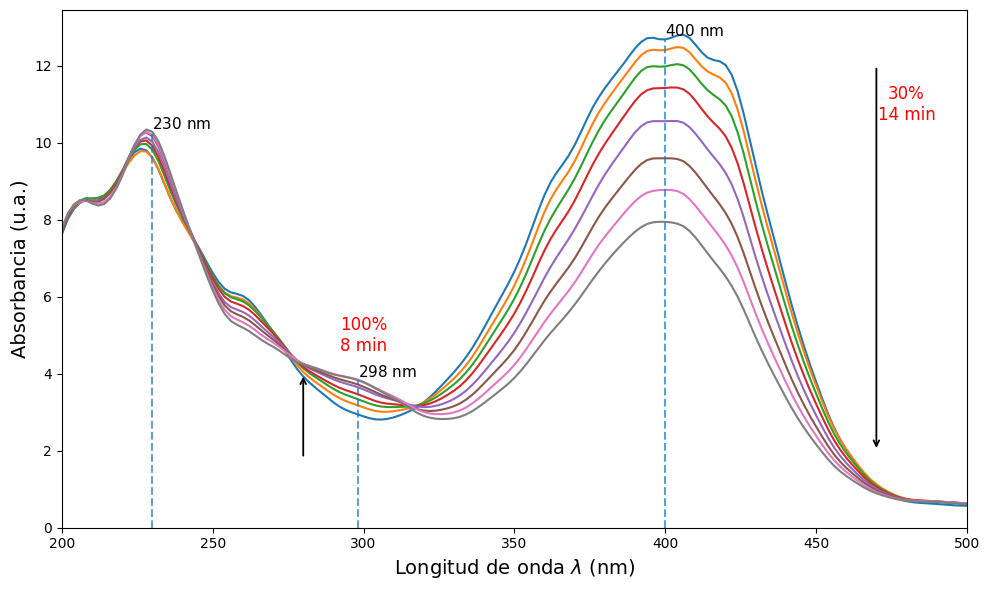


📊 TABLA 1 (Abs a 398 nm):
    X    Abs_398
0   0  12.692417
1   2  12.403938
2   4  11.979086
3   6  11.419643
4   8  10.561624
5  10   9.597639
6  12   8.770226
7  14   7.948810


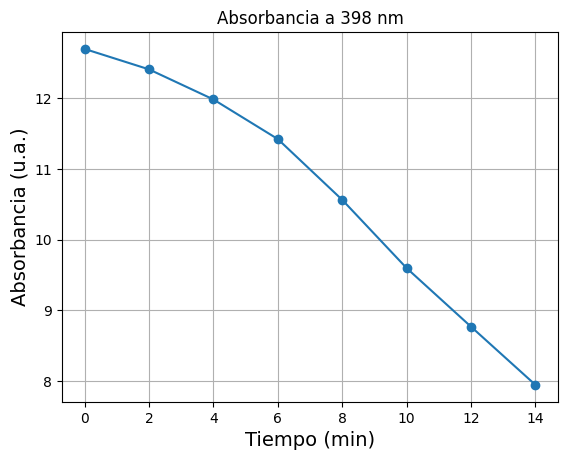


📊 TABLA 2 (Normalizado):
    X  Abs_norm
0   0  1.000000
1   2  0.977272
2   4  0.943799
3   6  0.899722
4   8  0.832121
5  10  0.756171
6  12  0.690982
7  14  0.626264


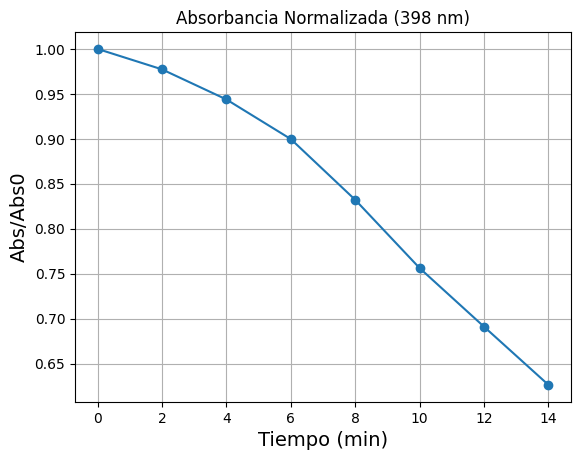


📊 TABLA 3 (Log):
    X  ln(Abs_norm)
0   0      0.000000
1   2     -0.022991
2   4     -0.057842
3   6     -0.105670
4   8     -0.183778
5  10     -0.279488
6  12     -0.369642
7  14     -0.467983


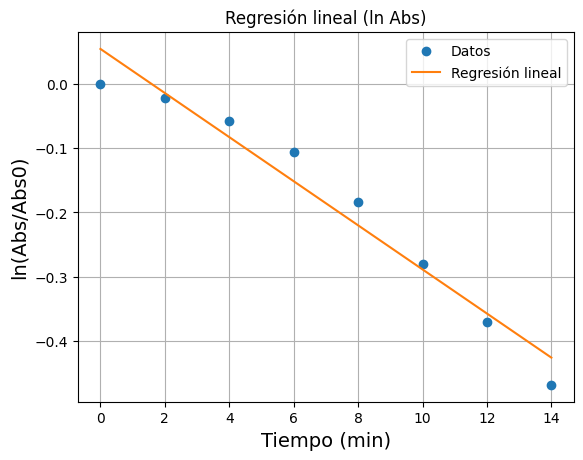


📈 Pendiente (slope): -0.03423915434718977
📊 Coeficiente de determinación R²: 0.9559
⚡ Constante de velocidad k: 0.034239

⚡ Eficiencia a 398 nm: 37.37%

📌 k′ = k/m = 0.684783 (unidades dependen de k y m)
📌 Qt = 0.002640 g/g
📌 ΔG‡ = 91.5336 kJ/mol

 TON y TOF
Masa degradada del contaminante = 0.000010 g
Moles de contaminante degradado = 7.474711e-08 mol
Moles de catalizador = 4.635209e-04 mol

🔁 TON = 0.000161
⚡ TOF = 0.000012 min^-1


In [61]:
plt.figure(figsize=(10, 6))

# =====================================================
# DATOS EXPERIMENTALES (MODIFICAR SEGÚN TU EXPERIMENTO)
# =====================================================

m = 0.05   # masa del catalizador (g)
M = 0.000027822     # masa del contaminante orgánico (g)

masa_molar_catalizador = 107.87   # g/mol (ejemplo: Ag = 107.87, Au = 196.97)
masa_molar_contaminante = 139.11  # g/mol (ejemplo: 4-NF ≈ 139.11 g/mol)

T = 298.15  # temperatura en K

# Constantes físicas
kb = 1.380649e-23   # Constante de Boltzmann (J/K)
h = 6.62607015e-34  # Constante de Planck (J·s)
R = 8.314           # Constante de los gases (J/mol·K)

####### Datos para las graficas #################################

####### lineas punteadas de UV_VIS ##############################
valores_primera = [ 400 ]   # respecto a la primera curva
valores_ultima = [230, 298]    # respecto a la última curva

####### longitud de onda (nm) en la que se realizaran los estadisticos########

lambda_objetivo = 398   # 🔧 CAMBIA AQUÍ la longitud de onda (nm)

##############################################################################
### Grafica de UV_VIS
##############################################################################

y_primera = {}
y_ultima = {}

for i, archivo in enumerate(archivos):
    df = extraer_nm_abs(archivo)

    # Invertir solo al graficar
    df_plot = df.iloc[::-1]

    #nmbre de las etiquetas
    plt.plot(
        df_plot["nm"],
        df_plot["Abs"],
        label=rf"$\mathrm{{Lluvia\ 4NF}}_{{{i+1}}}$"
   )

    # Primera curva
    if i == 0:
        for x_nm in valores_primera:
            y_nm = df_plot.loc[(df_plot["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_primera[x_nm] = y_nm

    # Última curva
    if i == len(archivos) - 1:
        for x_nm in valores_ultima:
            y_nm = df_plot.loc[(df_plot["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_ultima[x_nm] = y_nm


# Dibujar líneas primera curva
for x_nm, y_nm in y_primera.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

# Dibujar líneas última curva
for x_nm, y_nm in y_ultima.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

########################################################################
##LINEAS Y FLECHAS
########################################################################
# Líneas verticales
#plt.plot([200, 250], [0, 15], linestyle='dashed' , alpha=0.7)

# Flecha hacia abajo
plt.annotate(
    '',
    xy=(470, 2),      # punto final (abajo)
    xytext=(470, 12),  # punto inicial (arriba)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# etiqueta arriba de la flecha
plt.text(480, 11, "30%\n14 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

# Flecha hacia arriba
plt.annotate(
    '',
    xy=(280, 4),      # punto final (abajo)
    xytext=(280, 1.8),  # punto inicial (arriba)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# etiqueta arriba de la flecha
plt.text(300, 5, "100%\n8 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

########################################################################

#plt.grid(alpha=0.3) #mayado
#plt.legend()## esto es para la etiquetas de cada linea
plt.xlabel(r'Longitud de onda $\lambda$ (nm)', fontsize=14)
plt.ylabel(r'Absorbancia (u.a.)', fontsize=14)
#plt.title(r'Espectros UV-Vis de $\mathrm{Lluvia\ 4NF}$', fontsize=16)


# Límites de los ejes
plt.xlim(200, 500)
plt.ylim(0, None)


plt.tight_layout()
plt.show()

##########################################################################
# Analisis de datos
##########################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. EXTRAER Abs a λ variable
# =========================

abs_lambda = []

for archivo in archivos:
    df = extraer_nm_abs(archivo)

    # Buscar el valor más cercano a la longitud de onda elegida
    fila = df.iloc[(df["nm"] - lambda_objetivo).abs().argsort()[:1]]
    abs_lambda.append(fila["Abs"].values[0])

# Eje X (0,2,4,...)
x = np.arange(0, 2 * len(abs_lambda), 2)

# Tabla 1
tabla1 = pd.DataFrame({
    "X": x,
    f"Abs_{lambda_objetivo}": abs_lambda
})

print(f"\n📊 TABLA 1 (Abs a {lambda_objetivo} nm):")
print(tabla1)

# Gráfica 1
plt.figure()
plt.plot(x, abs_lambda, marker='o')
plt.title(f"Absorbancia a {lambda_objetivo} nm")
plt.xlabel(r'Tiempo (min)', fontsize=14)
plt.ylabel(r'Absorbancia (u.a.)', fontsize=14)
plt.grid()
plt.show()

# =========================
# 2. NORMALIZACIÓN
# =========================

abs0 = abs_lambda[0]
abs_norm = [a / abs0 for a in abs_lambda]

tabla2 = pd.DataFrame({
    "X": x,
    "Abs_norm": abs_norm
})

print("\n📊 TABLA 2 (Normalizado):")
print(tabla2)

# Gráfica 2
plt.figure()
plt.plot(x, abs_norm, marker='o')
plt.title(f"Absorbancia Normalizada ({lambda_objetivo} nm)")
plt.xlabel(r'Tiempo (min)', fontsize=14)
plt.ylabel("Abs/Abs0", fontsize=14)
plt.grid()
plt.show()

# =========================
# 3. LOG + REGRESIÓN LINEAL
# =========================

# Para cinética de pseudo-primer orden:
# ln(Ct/C0) = -kt
# Donde:
# Ct es la concentracion respecto al tiempo
# C0 es la concentracion inicial
# K es la velocidad de reacción

log_abs = np.log(abs_norm)

# Regresión lineal
coef = np.polyfit(x, log_abs, 1)
pendiente, intercepto = coef


k = -pendiente

y_fit = pendiente * x + intercepto

# Cálculo de R²
ss_res = np.sum((log_abs - y_fit) ** 2)
ss_tot = np.sum((log_abs - np.mean(log_abs)) ** 2)
r2 = 1 - (ss_res / ss_tot)

tabla3 = pd.DataFrame({
    "X": x,
    "ln(Abs_norm)": log_abs
})

print("\n📊 TABLA 3 (Log):")
print(tabla3)

# Gráfica 3
plt.figure()
plt.plot(x, log_abs, 'o', label="Datos")
plt.plot(x, y_fit, '-', label="Regresión lineal")

plt.title("Regresión lineal (ln Abs)")
plt.xlabel(r'Tiempo (min)', fontsize=14)
plt.ylabel("ln(Abs/Abs0)", fontsize=14)

plt.legend()
plt.grid()
plt.show()

print(f"\n📈 Pendiente (slope): {pendiente}")
print(f"📊 Coeficiente de determinación R²: {r2:.4f}")
print(f"⚡ Constante de velocidad k: {k:.6f}")

# =========================
# 4. EFICIENCIA
# =========================

#Eficiencia = C0-Cf/C0 * 100
# Donde:
# Cf es la concentracion final
# C0 es la concentracion inicial

abs_final = abs_lambda[-1]

eficiencia = ((abs0 - abs_final) / abs0) * 100

print(f"\n⚡ Eficiencia a {lambda_objetivo} nm: {eficiencia:.2f}%")


# =========================
# 5. Parametro de actividad (k ′)
# =========================

#parametro de actividad
# k ′ = k / m
# Donde:
# m es la masa del catalizador
# k la velocidad de la reacción

k_prima = k / m

print(f"\n📌 k′ = k/m = {k_prima:.6f} (unidades dependen de k y m)")

# =========================
# 6. Capacidad de reducción (Qt)
# =========================

# Qt = (C0 - Cf) × M / m
# Donde:
# m es la masa del catalizador
# M es la masa del contaminante
# Cf es la concentracion final
# C0 es la concentracion inicial

Qt = (abs0 - abs_final) * M / m

print(f"📌 Qt = {Qt:.6f} g/g")

# =========================
# 7. ΔG‡ (Energía libre de activación)
# =========================

#    Ecuación de Eyring
#    ΔG‡ = RT ln(kB*T / h*k)
# Donde:
# T es la temperatura en K
# R es la constante de los gases
# Kb es la Constante de Boltzmann
# K es la velocidad de reaccion
# h es la constante de Planck

# Convertir k de min^-1 a s^-1
k_seg = k / 60

delta_G = R * T * np.log((kb * T) / (h * k_seg))
# convertir a kJ/mol
delta_G_kJ = delta_G / 1000
print(f"📌 ΔG‡ = {delta_G_kJ:.4f} kJ/mol")

# =========================
# 8. Número de recambio (TON)
# y Frecuencia de recambio (TOF)
# =========================

# TON = moles_contaminante / moles_catalizador
# TOF = TON/tiempo_reaccion

tiempo_reaccion_min = x[-1]       # usa automáticamente el último tiempo experimental

fraccion_degradada = eficiencia / 100

# =========================
# CÁLCULOS
# =========================

# Moles degradados del contaminante
masa_contaminante_degradada = M * fraccion_degradada

moles_contaminante = (
    masa_contaminante_degradada / masa_molar_contaminante
)

# Moles del catalizador
moles_catalizador = m / masa_molar_catalizador

# TON
TON = moles_contaminante / moles_catalizador

# TOF
TOF = TON / tiempo_reaccion_min

# =========================
# RESULTADOS
# =========================

print("\n=========================")
print(" TON y TOF")
print("=========================")

print(f"Masa degradada del contaminante = {masa_contaminante_degradada:.6f} g")
print(f"Moles de contaminante degradado = {moles_contaminante:.6e} mol")
print(f"Moles de catalizador = {moles_catalizador:.6e} mol")

print(f"\n🔁 TON = {TON:.6f}")
print(f"⚡ TOF = {TOF:.6f} min^-1")

